# Corpus Preparation Pipeline - Data Exploration

## 1. Setup
Set environment variables, imports and constants.

In [2]:
import dotenv
import os
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import corpus_prep_pipeline as corpus_prep
from corpus_prep_utils import dataset_names, data_step_names, filters, partition_rules
import corpus_prep_utils
import importlib
importlib.reload(corpus_prep_utils)

# Reload the variables in your '.env' file (override the existing variables)
dotenv.load_dotenv("../.env", override=True)

input_data_root_path = os.environ.get("INPUT_DATA_ROOT_PATH")

def format_number(x, p):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.1f}K'
    else:
        return f'{x:.0f}'
    
# #######################################
#      SEQUENCE PLOTS                   #
# #######################################
#     
def plot_seq_count_by_family(sequence_df):
    # Explore sequence count by family
    # Aggregate by family_name and count occurrences
    family_sequence_counts = sequence_df['family_name'].value_counts().reset_index()
    family_sequence_counts.columns = ['family_name', 'sequence_count']
    total_sequences = family_sequence_counts['sequence_count'].sum()
    plt.figure(figsize=(8, 8))
    sns.set_palette("pastel")
    plt.pie(family_sequence_counts['sequence_count'], labels=family_sequence_counts['family_name'], autopct='%1.1f%%', startangle=140)
    plt.title('Sequences per Family - #Seqs '+str(total_sequences))

    # 2. Show the pie chart
    plt.show()

def seq_plot_sequence_length_distr(sequence_df, bins, long_tail=-1):
    #Explore sequence length distribution
    sequence_df['sequence_length'] = sequence_df['sequence'].apply(len)
    group_column = 'sequence_length'
    if long_tail > -1:
        # Create a new column where lengths greater than X are grouped
        sequence_df['length_group'] = sequence_df['sequence_length'].apply(lambda x: x if x <= long_tail else long_tail)
        group_column = 'length_group'
        
    # 4. Create a histogram using Seaborn
    plt.figure(figsize=(10, 6))
    ts_sl_histplot = sns.histplot(data=sequence_df, x=group_column, bins=bins, kde=False)

    #ts_sl_histplot = sns.histplot(sequence_df['length_group'], kde=False, bins=bins)

    # Add labels to each bar
    for p in ts_sl_histplot.patches:
        height = p.get_height()
        if height > 0:
            ts_sl_histplot.text(p.get_x() + p.get_width() / 2., height + 10, int(height), ha="center")

    # 5. Set custom x-axis ticks
    plt.xticks(np.arange(0, long_tail + 500, 1000))
    plt.title('Histogram of Sequence Lengths')
    plt.xlabel('Sequence Length')
    plt.ylabel('Frequency')

    # 5. Show the histogram
    plt.show()

def seq_plot_aminoacid_frequencies(letter_frequencies):
    # Extract letters and probabilities
    letters = list(letter_frequencies.keys())
    probabilities = list(letter_frequencies.values())

    # Create the bar plot using Seaborn
    plt.figure(figsize=(10, 6))
    sns.barplot(x=letters, y=probabilities, hue=letters, dodge=False, palette="pastel")  # Assign 'letters' to 'hue'

    # Add labels and title
    plt.xlabel("Aminoacid", fontsize=12)
    plt.ylabel("Relative frequency", fontsize=12)
    plt.title("Relative Freq Distribution of Aminoacids", fontsize=14)
    plt.legend([],[], frameon=False) # Remove legend

    # Show the plot
    plt.show()

## 2. TestGroup dataset exploration

### 2.1. Sequence dataset

In [4]:

test_sequence_df = corpus_prep.load_sequence_dataset(input_data_root_path, dataset_names.TEST_GROUP)
print(len(test_sequence_df))
print(test_sequence_df.head(10))

   id family_name                    name  \
0   0      Globin  UniRef90_UPI00047DF566   
1   1      Globin  UniRef90_UPI00041C2C82   
2   2      Globin         UniRef90_B5FX70   
3   3      Globin         UniRef90_D3PG04   
4   4      Globin         UniRef90_C7PWU1   
5   5      Globin         UniRef90_M8E6D5   
6   6      Globin  UniRef90_UPI0006500DD2   
7   7      Globin         UniRef90_W2TL52   
8   8      Globin         UniRef90_B2IF30   
9   9      Globin     UniRef90_A0A072VP06   

                                            sequence  
0  MLSEKTIQIIKSTVPVLEKHGVEITKRFYRNMFAAHPELLNIFNHA...  
1  MLSTQSHPIIEATLPLVGEKMPEIAKNFYARLFTAHPELFDGLFSR...  
2  MVNWTAEEKQLVTTLWGRVNVDECGAEALARLLVAYPWTQRFFVSF...  
3  MVIGKKLKRHGGIVMKALGKLVGFLETGKIIAIVNTIKGIANSHSK...  
4  MDGENLNGDLLAGRAQALALVRQGFAAVSARPEVFTNSLYEDFFTS...  
5  MLSPQTIAIIKSTVPVLEVHGKAITTRFYEMMFASHPELLNIFNHA...  
6  MVHLTCEEKAFINSIWGHVNVEELGGEALGRLLVVYPWTQRFFDSF...  
7  MVSPADVKKHTVASLGVAPVGKTPEKIQNGKDFYKFFFTTHPELRK...  
8  MAEPLS

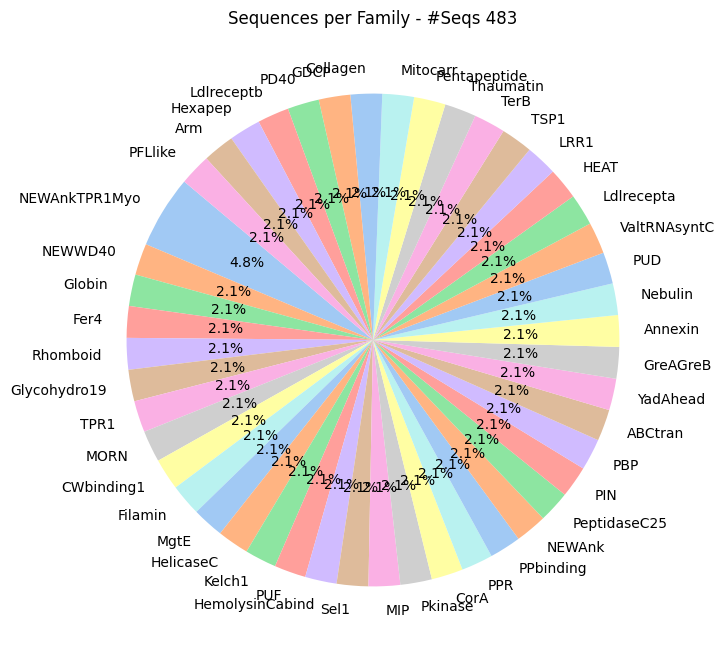

In [5]:
plot_seq_count_by_family(test_sequence_df)

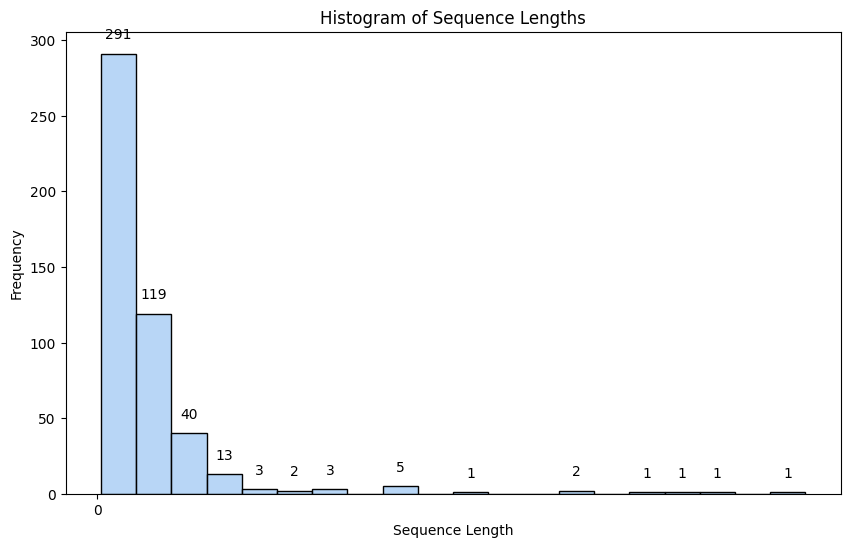

In [60]:
seq_plot_sequence_length_distr(test_sequence_df, bins=20)

{'A': 0.08949698004915467, 'R': 0.05366099299302736, 'N': 0.043561110014334395, 'D': 0.060238792134108134, 'C': 0.017164078750475667, 'E': 0.05983536904629065, 'Q': 0.04035089225170167, 'G': 0.07646155034634301, 'H': 0.02246580202512668, 'I': 0.05051658183337196, 'L': 0.09398613483486834, 'K': 0.04881991593921759, 'M': 0.02004812465487298, 'F': 0.03435676906746321, 'P': 0.04907169772452211, 'S': 0.06918276782572122, 'T': 0.06009573430154874, 'W': 0.013232849511743618, 'Y': 0.030800351350036767, 'V': 0.0666535053460712, 'U': 0.0, 'O': 0.0, 'X': 0.0, 'B': 0.0, 'Z': 0.0, 'J': 0.0}


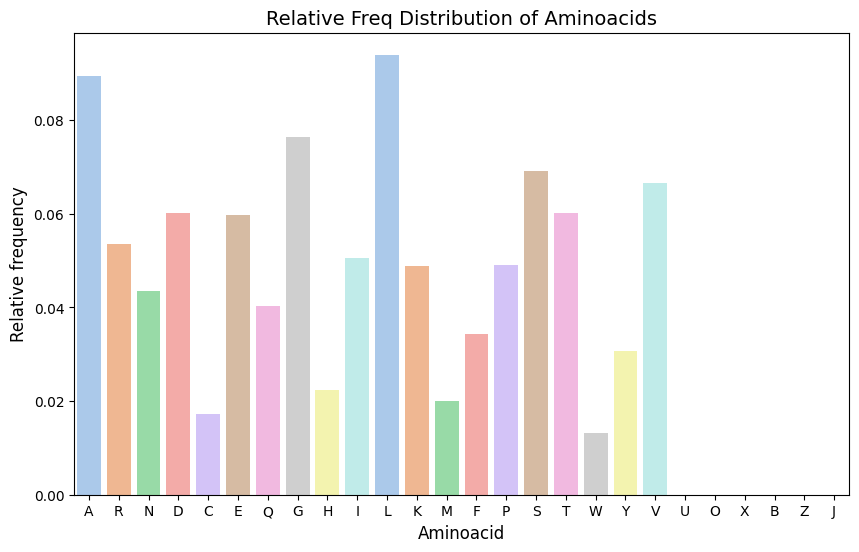

In [64]:
letter_probs = corpus_prep.count_aminoacid_frequency(test_sequence_df)

seq_plot_aminoacid_frequencies(letter_probs)

### 2.2 MR Dataset

In [8]:
mr_test_df = corpus_prep.load_mr_dataset(input_data_root_path, dataset_names.TEST_GROUP)
print(mr_test_df.head(10))


   id type       pattern  length  instances  \
0   0  SMR  AAAAAAAAAAAA      12          4   
1   1   NN   AAAAAAAAAAA      11          8   
2   2   NE    AAAAAAAAAA      10         12   
3   3   NE     AAAAAAAAA       9         16   
4   4   NN      AAAAAAAA       8         21   
5   5   NE       AAAAAAA       7         26   
6   6  SMR       AAAAAAT       7          2   
7   7   NE        AAAAAA       6         34   
8   8  SMR     AAAAAPAAP       9          2   
9   9   NE      AAAAAPAA       8          3   

                                   affected_proteins  
0  [{'protein_id': 139, 'starting_positions': [67...  
1  [{'protein_id': 139, 'starting_positions': [67...  
2  [{'protein_id': 139, 'starting_positions': [67...  
3  [{'protein_id': 139, 'starting_positions': [67...  
4  [{'protein_id': 139, 'starting_positions': [67...  
5  [{'protein_id': 139, 'starting_positions': [67...  
6  [{'protein_id': 139, 'starting_positions': [31...  
7  [{'protein_id': 139, 'starting_position

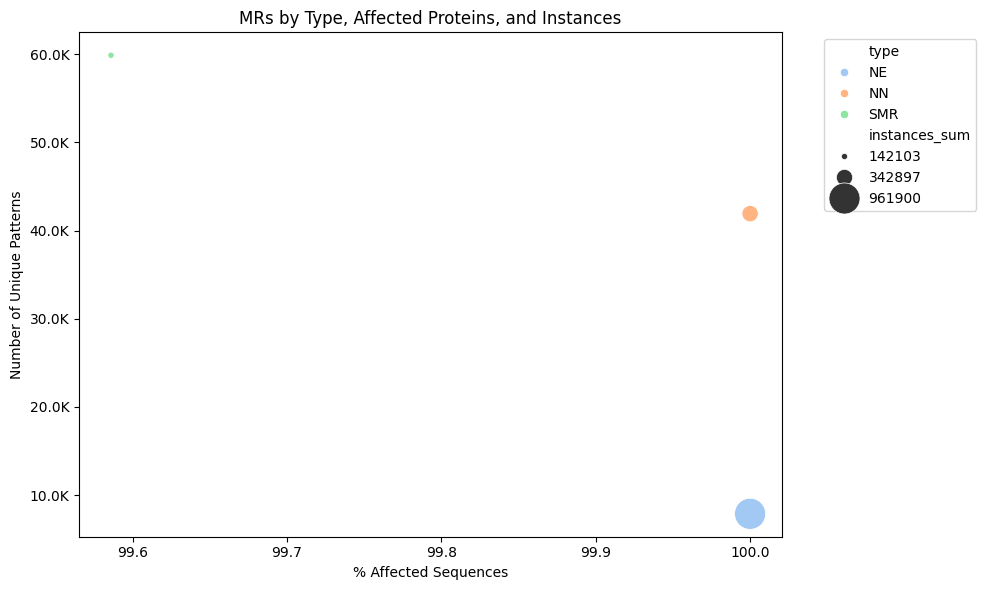

In [44]:
def plot_mr_scatter(sequence_df, mr_df):
    total_sequences = len(sequence_df)

    exploded_mr_df = mr_df.explode("affected_proteins")
    exploded_mr_df['protein_id'] = exploded_mr_df["affected_proteins"].apply(lambda x: x['protein_id'])
    exploded_mr_df['instance_count'] = exploded_mr_df["affected_proteins"].apply(lambda x: len(x['starting_positions']))

    # Group by type and calculate required metrics
    grouped_mr_df = exploded_mr_df.groupby('type').agg({
        'pattern': 'nunique',
        'instance_count': 'sum',
        'protein_id': 'nunique'
    }).reset_index()

    grouped_mr_df.columns = ['type', 'unique_patterns', 'instances_sum', 'unique_affected_proteins']

    grouped_mr_df["unique_affected_proteins"] = (grouped_mr_df["unique_affected_proteins"] / total_sequences)*100

    # Step 2: Create the scatterplot
    plt.figure(figsize=(10, 6))
    mr_scatter = sns.scatterplot(data=grouped_mr_df, 
                    x='unique_affected_proteins', 
                    y='unique_patterns', 
                    size='instances_sum', 
                    hue='type',
                    sizes=(20, 500),  # Adjust the range of circle sizes
                    legend='full')

    plt.title('MRs by Type, Affected Proteins, and Instances')
    plt.xlabel('% Affected Sequences')
    plt.ylabel('Number of Unique Patterns')

    # Format y-axis
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_number))

    # Get the current legend
    leg = plt.gca().get_legend()
    # Format the 'instances_sum' labels in the legend
    for text in leg.texts:
        if text.get_text().isdigit():
            value = int(text.get_text())
            text.set_text(format_number(value, None))

    # Move legend outside of plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust layout to prevent cutting off labels
    plt.tight_layout()

    plt.show()

plot_mr_scatter(test_sequence_df, mr_test_df)

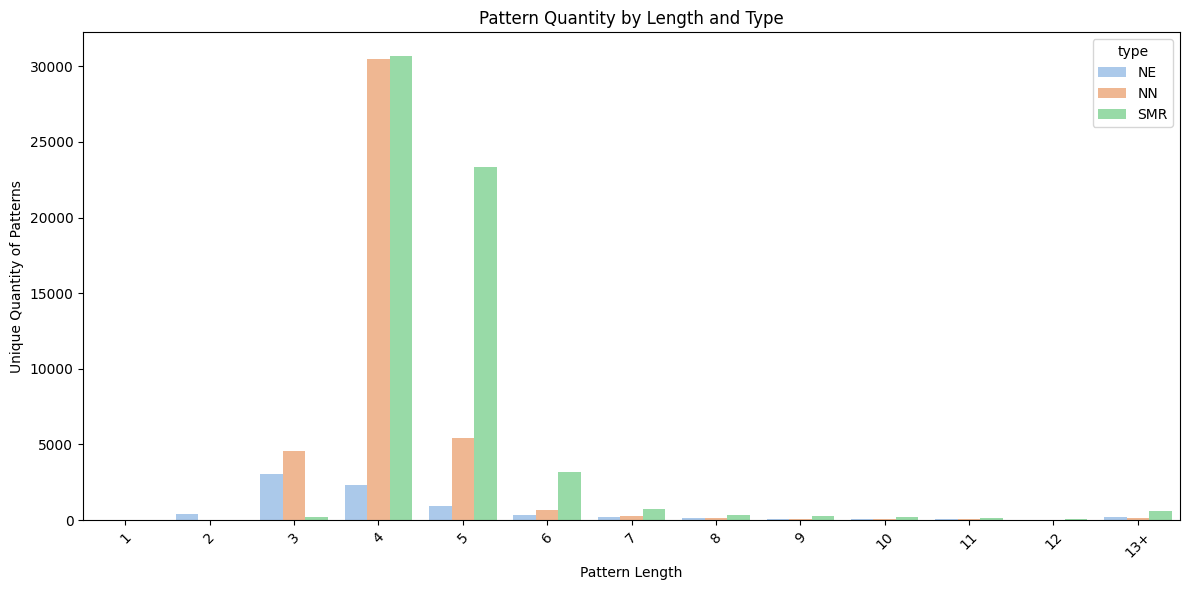

In [49]:
def plot_mr_stacked(mr_df):
    # First, let's prepare the data
    # Group patterns longer than 12 into a single category
    mr_df['length_group'] = mr_df['length'].apply(lambda x: x if x <= 12 else '13+')
    data_for_plot = mr_df.groupby(['length_group', 'type'])['pattern'].nunique().reset_index()
    # Create the stacked bar chart
    plt.figure(figsize=(12, 6))
    chart = sns.barplot(x='length_group', y='pattern', hue='type', data=data_for_plot)

    # Customize the chart
    plt.title('Pattern Quantity by Length and Type')
    plt.xlabel('Pattern Length')
    plt.ylabel('Unique Quantity of Patterns')

    # Rotate x-axis labels if there are many pattern lengths
    plt.xticks(rotation=45)

    # Adjust layout to prevent cutting off labels
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_mr_stacked(mr_test_df)

#### 2.2.1 Filter NE

   id type       pattern  length  instances  \
0   0  SMR  AAAAAAAAAAAA      12          4   
1   1   NN   AAAAAAAAAAA      11          8   
2   4   NN      AAAAAAAA       8         21   
2   4   NN      AAAAAAAA       8         21   
3   6  SMR       AAAAAAT       7          2   
3   6  SMR       AAAAAAT       7          2   
4   8  SMR     AAAAAPAAP       9          2   
5  10   NN        AAAAAP       6          5   
5  10   NN        AAAAAP       6          5   
5  10   NN        AAAAAP       6          5   

                                   affected_proteins  
0  {'protein_id': 139, 'starting_positions': [670...  
1  {'protein_id': 139, 'starting_positions': [670...  
2  {'protein_id': 139, 'starting_positions': [670...  
2   {'protein_id': 192, 'starting_positions': [109]}  
3   {'protein_id': 139, 'starting_positions': [318]}  
3    {'protein_id': 411, 'starting_positions': [29]}  
4  {'protein_id': 366, 'starting_positions': [152...  
5     {'protein_id': 53, 'starting_positio

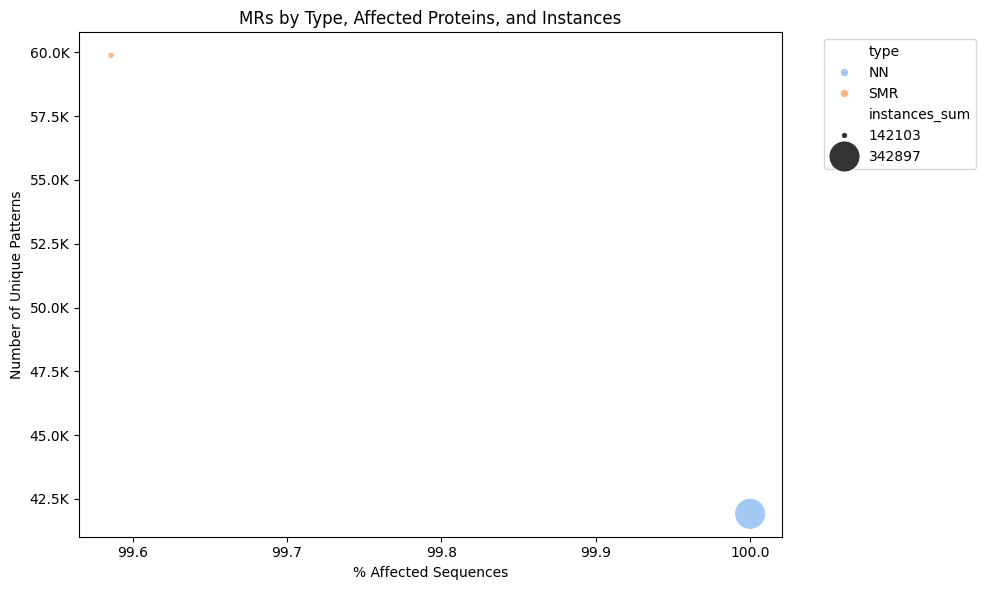

In [42]:
mr_test_filtered_ne_df = corpus_prep_utils.load_dataset(input_data_root_path, dataset_names.TEST_GROUP, "20240804_16_41_07", data_step_names.S1_FILTERED_MR, filters.MR_FILTER_DROP_NE.name, partition_rules.PARTITION_RULE_USE_ALL["name"])
plot_mr_scatter(test_sequence_df, mr_test_filtered_ne_df)


## 3. Family Group Dataset Exploration

### 3.1 Sequence Dataset

In [3]:
family_sequence_df = corpus_prep.load_sequence_dataset(input_data_root_path, dataset_names.FAMILY)
print(len(family_sequence_df))
print(family_sequence_df.head(10))

696114
   id family_name                    name  \
0   0      Globin         UniRef90_O24520   
1   1      Globin     UniRef90_A0A060DWH1   
2   2      Globin     UniRef90_A0A0J1D7N2   
3   3      Globin         UniRef90_H2TTY1   
4   4      Globin         UniRef90_P01950   
5   5      Globin     UniRef90_A0A0G4II14   
6   6      Globin     UniRef90_A0A0B2VCL4   
7   7      Globin         UniRef90_B5M1W5   
8   8      Globin         UniRef90_G8ZUE8   
9   9      Globin  UniRef90_UPI0005763E56   

                                            sequence  
0  MESEGKIVFTEEQEALVVKSWSVMKKNSAELGLKLFIKIFEIAPTT...  
1  MAEALSNRTIDIVKATVPALEKGGTAVTDRMYQRLFRTPEIRDLFN...  
2  MISDASRPYIDASVPVLRQHGLAITKLFYENMLGAHPELTRIFNMG...  
3  MTSLSAKDKDTVRLFWGKLAPKREEVGANALCRLLSVYPQTKTYFA...  
4  VLSANDKANVKAAWDKVGGQAANYGAEALERTFASFPTTKTYFPHY...  
5  MAAASSWQQYLPPSCPASPNLTEERIDIVRKTWLTLKSGQGKGERD...  
6  MQKLWSWIVDKKSHSIRKWRSSVLGGATRSQPTNGSLKPIGGSDDE...  
7  MDSTKGIAFTEEEEALVVKSWASMKKNAGELGLKLFLKVFEIAPTA...  
8 

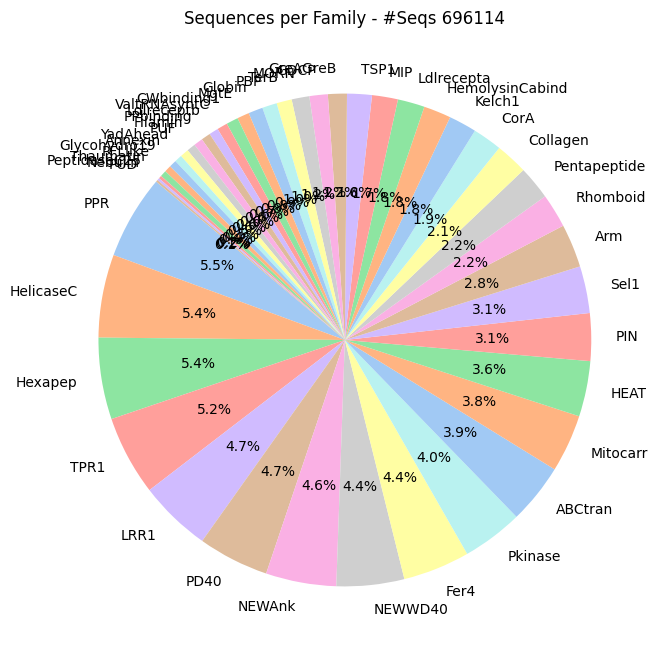

In [4]:
plot_seq_count_by_family(family_sequence_df)

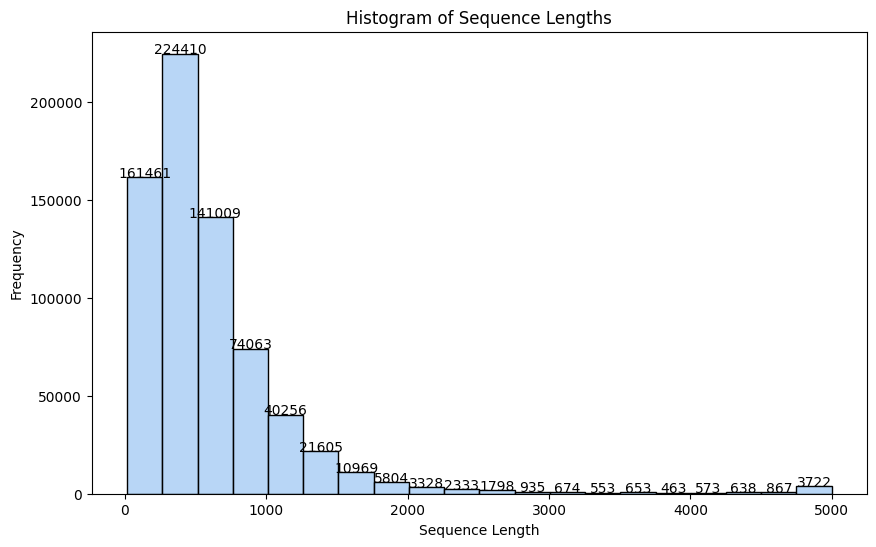

In [5]:
seq_plot_sequence_length_distr(family_sequence_df, bins=20, long_tail=5000)

{'A': 0.08637007251627421, 'R': 0.055173534772037014, 'N': 0.043110174570132186, 'D': 0.05860910470871743, 'C': 0.017195426015887964, 'E': 0.06078316997939946, 'Q': 0.03916611323239624, 'G': 0.07423417656716816, 'H': 0.023215384341934077, 'I': 0.05272086069302245, 'L': 0.10036949704560404, 'K': 0.04977688484770939, 'M': 0.020746006302095752, 'F': 0.03522106213261615, 'P': 0.04705700954336389, 'S': 0.07370667022600443, 'T': 0.055870506789332586, 'W': 0.012526007206139798, 'Y': 0.028747037809080417, 'V': 0.06540130070108437, 'U': 0.0, 'O': 0.0, 'X': 0.0, 'B': 0.0, 'Z': 0.0, 'J': 0.0}


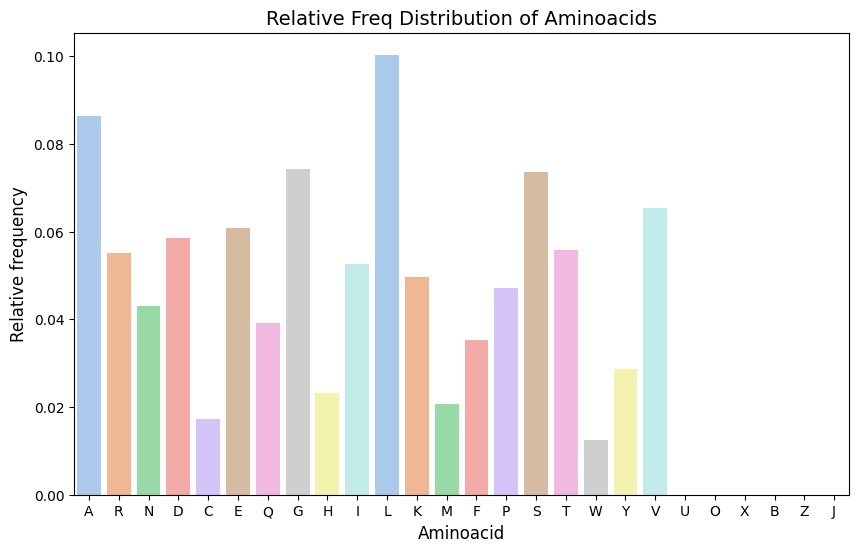

In [6]:
letter_probs = corpus_prep.count_aminoacid_frequency(family_sequence_df)

seq_plot_aminoacid_frequencies(letter_probs)

### 3.2 MR Dataset

In [7]:
mr_family_df = corpus_prep.load_mr_dataset(input_data_root_path, dataset_names.FAMILY)
print(mr_family_df.head(10))

: 